In [4]:
import os
os.chdir("../")
import requests
import json
import base64
from dotenv import load_dotenv
from openai import OpenAI
import matplotlib.pyplot as plt
# load environment variables API_KEY
load_dotenv(dotenv_path='env.env')

False

## 1. Set up

In [2]:
VLM = "qwen/qwen3-vl-8b-thinking"
prompt_relevance_attribution = """You are given three AI-generated images:

The first is the original face.
The second is generated by changing one latent direction.
The third is a difference mask showing where the change occurred.

Focus specifically on whether the presence of eyeglasses changes between the first and second images.
Outout a JSON object:

{"answer": "yes" or "no", "reasoning": "eyeglasses appear/disappear" or "eyeglasses remain the same"}

Use the mask to support your reasoning and ignore irrelevant changes such as lighting or color tone.
"""

prompt_labeling = """You are an image tagger for AI-generated portraits.
For each image, output a JSON object with the following fields: Determine whether the person in the image is wearing eyeglasses.
output a JSON object. 
{ "glasses": "Yes / No / Ambiguous"} If the image quality is poor or unclear, respond with “Ambiguous.”
"""

# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


## 2. Example of relevance attribution

In [3]:
# Path to your image
image_path = "./vlm_utils/b32_conv0_affine_6_comparison.png"

# Getting the Base64 string
base64_image = encode_image(image_path)

In [4]:
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=os.getenv("API_KEY"),
)

completion = client.chat.completions.create(
  extra_headers={
    "HTTP-Referer": "<YOUR_SITE_URL>", # Optional. Site URL for rankings on openrouter.ai.
    "X-Title": "<YOUR_SITE_NAME>", # Optional. Site title for rankings on openrouter.ai.
  },
  extra_body={},
  model=VLM,
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": prompt_relevance_attribution
        },
        {
          "type": "image_url",
          "image_url": {
            "url": f"data:image/jpeg;base64,{base64_image}"
          }
        }
      ]
    }
  ]
)

{
  "answer": "no",
  "reasoning": "eyeglasses remain the same"
}


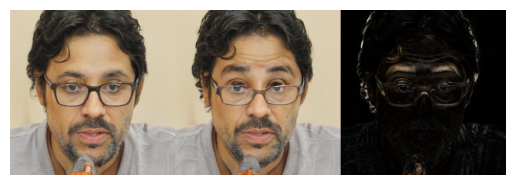

{
  "answer": "no",
  "reasoning": "eyeglasses remain the same"
}


In [5]:
plt.imshow(plt.imread(image_path))
plt.axis('off')
plt.show()
print(completion.choices[0].message.content)

## 3. Example of relabeling

In [7]:
# Path to your image
image_path = "./vlm_utils/b32_conv0_affine_6.png"

# Getting the Base64 string
base64_image = encode_image(image_path)

In [8]:
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=os.getenv("API_KEY"),
)

completion = client.chat.completions.create(
  extra_headers={
    "HTTP-Referer": "<YOUR_SITE_URL>", # Optional. Site URL for rankings on openrouter.ai.
    "X-Title": "<YOUR_SITE_NAME>", # Optional. Site title for rankings on openrouter.ai.
  },
  extra_body={},
  model=VLM,
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": prompt_labeling
        },
        {
          "type": "image_url",
          "image_url": {
            "url": f"data:image/jpeg;base64,{base64_image}"
          }
        }
      ]
    }
  ]
)

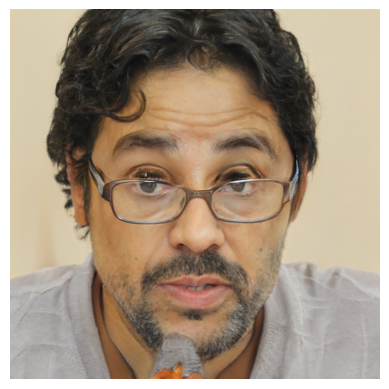

{"glasses": "Yes"}


In [9]:
plt.imshow(plt.imread(image_path))
plt.axis('off')
plt.show()
print(completion.choices[0].message.content)

## 3. Ollama Example

In [8]:
from vlm_utils.ollama_chat import OllamaVLMClient  # Ollama Example

vlm = OllamaVLMClient()
image_path = "./vlm_utils/b32_conv0_affine_6_comparison.png"
vlm.run_vlm_prompt(prompt_relevance_attribution, image_path)


--- Processing with qwen3-vl:8b-thinking ---


'{"answer": "no", "reasoning": "eyeglasses remain the same"}'

In [9]:
image_path = "./vlm_utils/b32_conv0_affine_6.png"
vlm.run_vlm_prompt(prompt_labeling, image_path)


--- Processing with qwen3-vl:8b-thinking ---


'{ "glasses": "Yes" }'